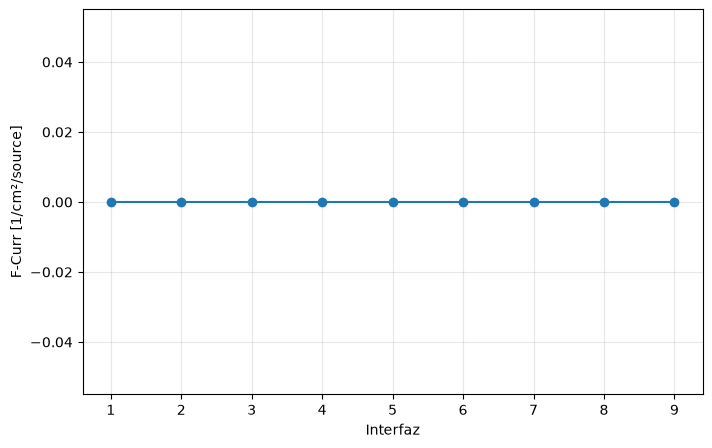

In [1]:
import numpy as np
import matplotlib.pyplot as plt

archivo = "../out/corriente_CR39.out"

interfaz = []
corriente = []
error_relativo = []

leyendo = False

with open(archivo, "r") as f:
    for linea in f:
        if "#  num" in linea and "proton" in linea:
            leyendo = True
            continue

        if leyendo:
            if linea.startswith("#"):
                if interfaz:
                    break
                continue

            partes = linea.split()

            if len(partes) == 4:
                try:
                    interfaz.append(int(partes[0]))
                    corriente.append(float(partes[2]))
                    error_relativo.append(float(partes[3]))
                except ValueError:
                    pass

interfaz = np.array(interfaz)
corriente = np.array(corriente)
error_relativo = np.array(error_relativo)

error = corriente * error_relativo

plt.figure(figsize=(8,5))
plt.errorbar(interfaz, corriente, yerr=error, marker="o", capsize=3)
plt.xlabel("Interfaz")
plt.ylabel("F-Curr [1/cm²/source]")
plt.xticks(interfaz)
plt.grid(alpha=0.3)
plt.show()

Esto significa que hay algun error en las definiciones de las superficies y por eso no esta corriendo nada